# **Space X  Falcon 9 First Stage Landing Prediction**


## Complete the Machine Learning Prediction

Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [15]:
%pip install pandas numpy seaborn sklearn matplotlib 


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates from a subpr

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns

We will import the following libraries for the lab


In [17]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [18]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data

In [23]:
import pandas as pd

# Directly read from the URL
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data = pd.read_csv(URL1)

# Preview the data
print(data.head())

   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False  False        NaN    1.0   
4    None None        1     False   False  False        NaN    1.0   

   ReusedCount Serial   Longitude   Latitude  Class  
0            0  B0003  -80.577366  28.561857      

In [24]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [25]:
import pandas as pd

# Directly read from the URL
URL2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv"
X = pd.read_csv(URL2)

# Preview the data
print(X.head())

   FlightNumber  PayloadMass  Flights  Block  ReusedCount  Orbit_ES-L1  \
0           1.0  6104.959412      1.0    1.0          0.0          0.0   
1           2.0   525.000000      1.0    1.0          0.0          0.0   
2           3.0   677.000000      1.0    1.0          0.0          0.0   
3           4.0   500.000000      1.0    1.0          0.0          0.0   
4           5.0  3170.000000      1.0    1.0          0.0          0.0   

   Orbit_GEO  Orbit_GTO  Orbit_HEO  Orbit_ISS  ...  Serial_B1058  \
0        0.0        0.0        0.0        0.0  ...           0.0   
1        0.0        0.0        0.0        0.0  ...           0.0   
2        0.0        0.0        0.0        1.0  ...           0.0   
3        0.0        0.0        0.0        0.0  ...           0.0   
4        0.0        1.0        0.0        0.0  ...           0.0   

   Serial_B1059  Serial_B1060  Serial_B1062  GridFins_False  GridFins_True  \
0           0.0           0.0           0.0             1.0         

In [26]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [28]:
# Create a NumPy array from the 'Class' column
Y = data['Class'].to_numpy()

# Quick check
print(type(Y))       # should be <class 'numpy.ndarray'>
print(Y[:10])        # preview first 10 values

<class 'numpy.ndarray'>
[0 0 0 0 0 0 1 1 0 0]


In [29]:
Y = data['Class']
print(type(Y))   # <class 'pandas.core.series.Series'>
print(Y[:10])

<class 'pandas.core.series.Series'>
0    0
1    0
2    0
3    0
4    0
5    0
6    1
7    1
8    0
9    0
Name: Class, dtype: int64


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [31]:
from sklearn import preprocessing

# Standardize the data
X = preprocessing.StandardScaler().fit(X).transform(X)

# Quick check
print(X[:5])   # preview first 5 rows

[[-1.71291154e+00 -1.94814463e-16 -6.53912840e-01 -1.57589457e+00
  -9.73440458e-01 -1.05999788e-01 -1.05999788e-01 -6.54653671e-01
  -1.05999788e-01 -5.51677284e-01  3.44342023e+00 -1.85695338e-01
  -3.33333333e-01 -1.05999788e-01 -2.42535625e-01 -4.29197538e-01
   7.97724035e-01 -5.68796459e-01 -4.10890702e-01 -4.10890702e-01
  -1.50755672e-01 -7.97724035e-01 -1.50755672e-01 -3.92232270e-01
   9.43398113e+00 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.50755672e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.50755672e-01 -1.05999788e-01 -1.50755672e-01
  -1.50755672e-01 -1.05999788e-01 -1.50755672e-01 -1.50755672e-01
  -1.05999788e-01 -1.05999788e-01 -1.50755672e-01 -1.50755672e-01
  -1.50755

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

we can see we only have 18 test samples.


In [34]:
X_train.shape

(72, 83)

In [36]:
X_test.shape

(18, 83)

In [37]:
Y_train.shape

(72,)

In [38]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Create logistic regression object
logreg = LogisticRegression()

# Define parameter grid (example values)
parameters = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Create GridSearchCV object with 10-fold cross-validation
logreg_cv = GridSearchCV(logreg, parameters, cv=10)

# Fit the model
logreg_cv.fit(X, Y)

# Print best parameters and best score
print("Best parameters:", logreg_cv.best_params_)
print("Best score:", logreg_cv.best_score_)

Best parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best score: 0.8222222222222222


In [41]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

In [42]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [43]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'solver': 'lbfgs'}
accuracy : 0.8222222222222222


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:

In [44]:
# Calculate accuracy on the test data
test_accuracy = logreg_cv.score(X_test, Y_test)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9444444444444444


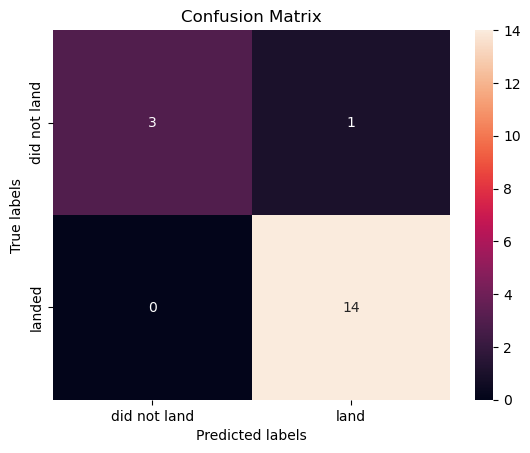

In [45]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [46]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Create SVM object
svm = SVC()

# Define parameter grid (example values)
parameters = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

# Create GridSearchCV object with 10-fold cross-validation
svm_cv = GridSearchCV(svm, parameters, cv=10)

# Fit the model
svm_cv.fit(X, Y)

# Print best parameters and best score
print("Best parameters:", svm_cv.best_params_)
print("Best score:", svm_cv.best_score_)

Best parameters: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Best score: 0.8444444444444444


In [47]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [48]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
accuracy : 0.8444444444444444


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [49]:
# Calculate accuracy on the test data
test_accuracy = svm_cv.score(X_test, Y_test)

print("Test accuracy:", test_accuracy)

Test accuracy: 1.0


We can plot the confusion matrix

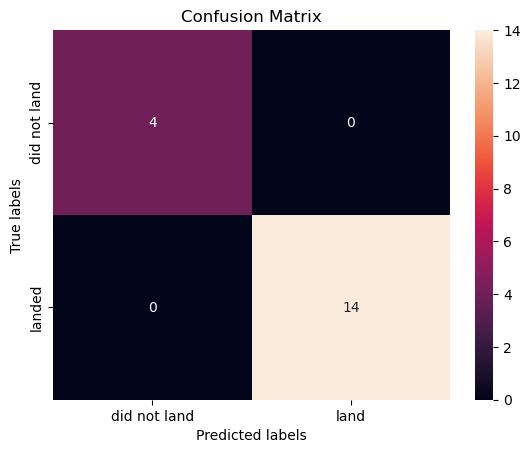

In [50]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Create Decision Tree object
tree = DecisionTreeClassifier()

# Define parameter grid (example values)
parameters = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create GridSearchCV object with 10-fold cross-validation
tree_cv = GridSearchCV(tree, parameters, cv=10)

# Fit the model
tree_cv.fit(X, Y)

# Print best parameters and best score
print("Best parameters:", tree_cv.best_params_)
print("Best score:", tree_cv.best_score_)

Best parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best score: 0.8555555555555555


In [52]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5}
accuracy : 0.8555555555555555


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [53]:
# Calculate accuracy on the test data
test_accuracy = tree_cv.score(X_test, Y_test)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9444444444444444


We can plot the confusion matrix

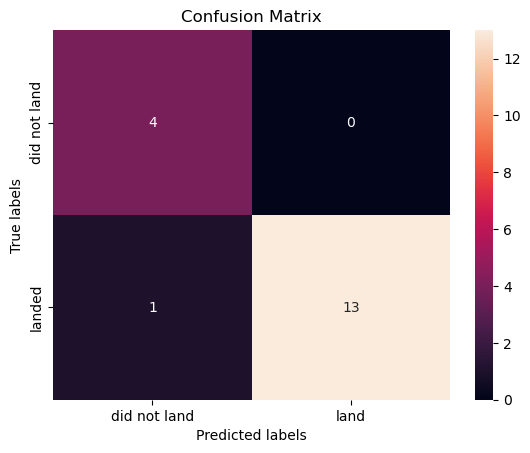

In [54]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Create KNN object
knn = KNeighborsClassifier()

# Define parameter grid (example values)
parameters = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# Create GridSearchCV object with 10-fold cross-validation
knn_cv = GridSearchCV(knn, parameters, cv=10)

# Fit the model
knn_cv.fit(X, Y)

# Print best parameters and best score
print("Best parameters:", knn_cv.best_params_)
print("Best score:", knn_cv.best_score_)

Best parameters: {'algorithm': 'auto', 'n_neighbors': 3, 'weights': 'uniform'}
Best score: 0.788888888888889


In [56]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 3, 'weights': 'uniform'}
accuracy : 0.788888888888889


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [57]:
# Calculate accuracy on the test data
test_accuracy = knn_cv.score(X_test, Y_test)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9444444444444444


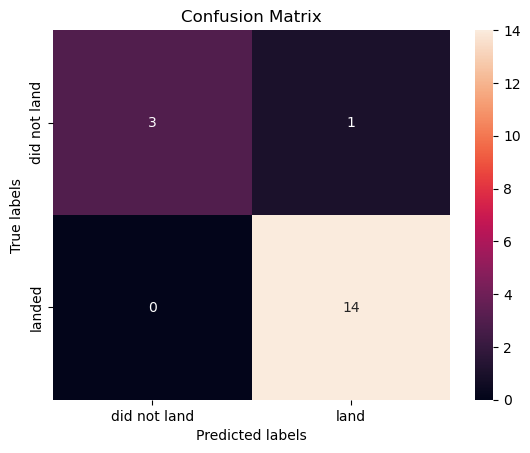

In [58]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  12


Find the method performs best:


In [59]:
# Compare test accuracies of all models
logreg_acc = logreg_cv.score(X_test, Y_test)
svm_acc = svm_cv.score(X_test, Y_test)
tree_acc = tree_cv.score(X_test, Y_test)
knn_acc = knn_cv.score(X_test, Y_test)

# Print results
print("Logistic Regression Test Accuracy:", logreg_acc)
print("SVM Test Accuracy:", svm_acc)
print("Decision Tree Test Accuracy:", tree_acc)
print("KNN Test Accuracy:", knn_acc)

# Find the best performing model
accuracies = {
    "Logistic Regression": logreg_acc,
    "SVM": svm_acc,
    "Decision Tree": tree_acc,
    "KNN": knn_acc
}

best_model = max(accuracies, key=accuracies.get)
print("Best performing model:", best_model, "with accuracy:", accuracies[best_model])

Logistic Regression Test Accuracy: 0.9444444444444444
SVM Test Accuracy: 1.0
Decision Tree Test Accuracy: 0.9444444444444444
KNN Test Accuracy: 0.9444444444444444
Best performing model: SVM with accuracy: 1.0


 #### Confusion Matrix and Classification Report Comparison Across Models

In [60]:
from sklearn.metrics import confusion_matrix, classification_report

# Logistic Regression
print("Logistic Regression")
print(confusion_matrix(Y_test, logreg_cv.predict(X_test)))
print(classification_report(Y_test, logreg_cv.predict(X_test)))

# SVM
print("SVM")
print(confusion_matrix(Y_test, svm_cv.predict(X_test)))
print(classification_report(Y_test, svm_cv.predict(X_test)))

# Decision Tree
print("Decision Tree")
print(confusion_matrix(Y_test, tree_cv.predict(X_test)))
print(classification_report(Y_test, tree_cv.predict(X_test)))

# KNN
print("KNN")
print(confusion_matrix(Y_test, knn_cv.predict(X_test)))
print(classification_report(Y_test, knn_cv.predict(X_test)))

Logistic Regression
[[ 3  1]
 [ 0 14]]
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.93      1.00      0.97        14

    accuracy                           0.94        18
   macro avg       0.97      0.88      0.91        18
weighted avg       0.95      0.94      0.94        18

SVM
[[ 4  0]
 [ 0 14]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00        14

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

Decision Tree
[[ 4  0]
 [ 1 13]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.93      0.96        14

    accuracy                           0.94        18
   macro avg       0.90      0.96

#### Confusion Matrix Heatmaps for Model Comparison

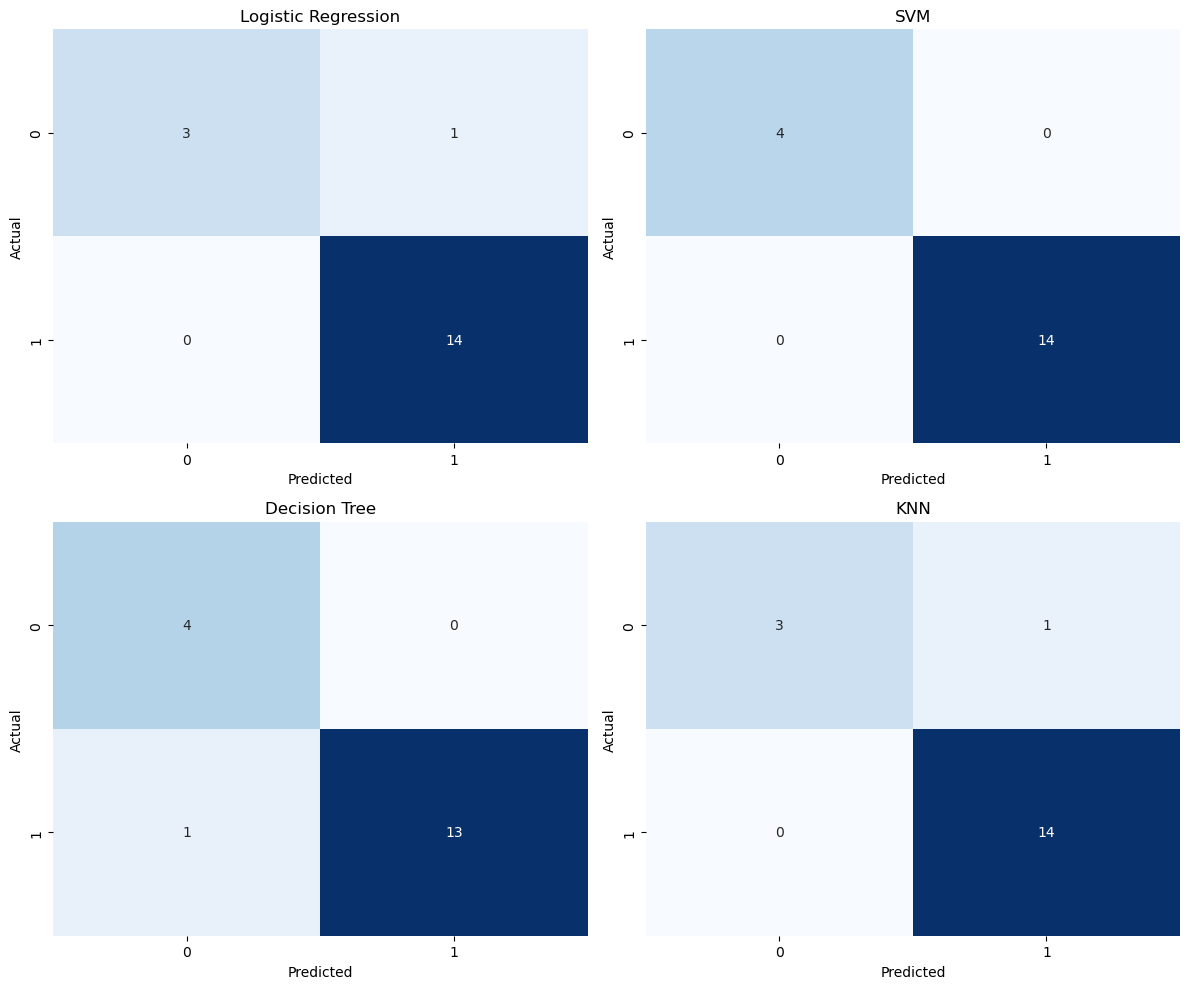

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": logreg_cv,
    "SVM": svm_cv,
    "Decision Tree": tree_cv,
    "KNN": knn_cv
}

plt.figure(figsize=(12, 10))

for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)  # 2x2 grid of plots
    cm = confusion_matrix(Y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

#### Confusion Matrix Heatmaps with Classification Metrics Summary

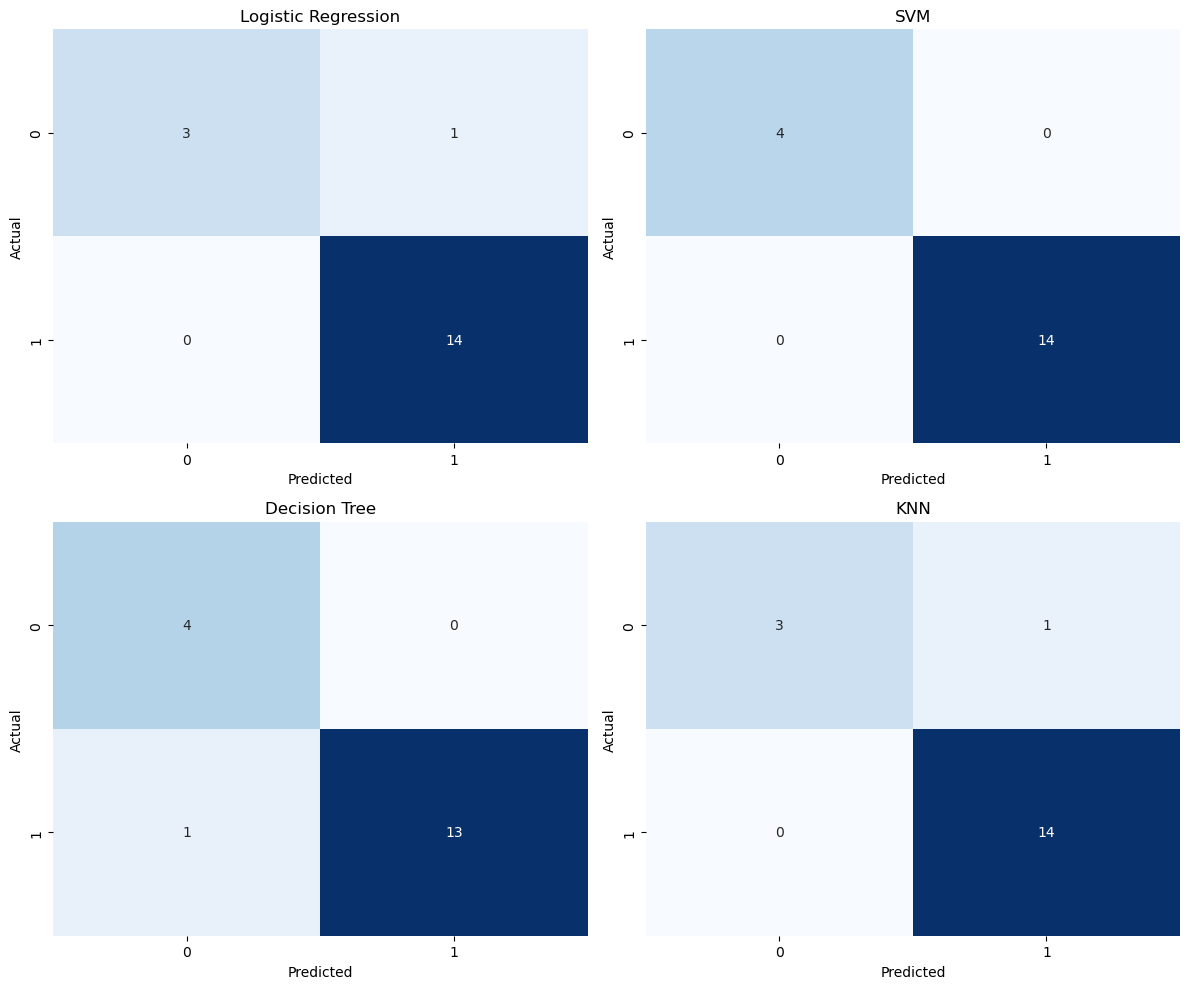

                     Accuracy  Precision (macro)  Recall (macro)  \
Logistic Regression  0.944444           0.966667        0.875000   
SVM                  1.000000           1.000000        1.000000   
Decision Tree        0.944444           0.900000        0.964286   
KNN                  0.944444           0.966667        0.875000   

                     F1-score (macro)  
Logistic Regression          0.911330  
SVM                          1.000000  
Decision Tree                0.925926  
KNN                          0.911330  


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Logistic Regression": logreg_cv,
    "SVM": svm_cv,
    "Decision Tree": tree_cv,
    "KNN": knn_cv
}

# Plot confusion matrices
plt.figure(figsize=(12, 10))
for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)
    cm = confusion_matrix(Y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Collect classification reports into a DataFrame
reports = {}
for name, model in models.items():
    report = classification_report(Y_test, model.predict(X_test), output_dict=True)
    reports[name] = {
        "Accuracy": report["accuracy"],
        "Precision (macro)": report["macro avg"]["precision"],
        "Recall (macro)": report["macro avg"]["recall"],
        "F1-score (macro)": report["macro avg"]["f1-score"]
    }

df_reports = pd.DataFrame(reports).T
print(df_reports)

In [67]:
#### Test Accuracy Comparison Across Classification Models

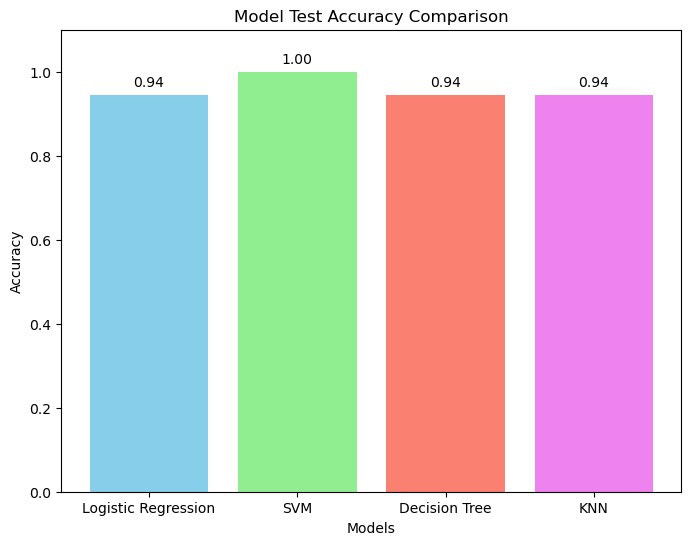

In [63]:
import matplotlib.pyplot as plt

# Collect test accuracies
accuracies = {
    "Logistic Regression": logreg_cv.score(X_test, Y_test),
    "SVM": svm_cv.score(X_test, Y_test),
    "Decision Tree": tree_cv.score(X_test, Y_test),
    "KNN": knn_cv.score(X_test, Y_test)
}

# Plot bar chart
plt.figure(figsize=(8, 6))
plt.bar(accuracies.keys(), accuracies.values(), color=['skyblue', 'lightgreen', 'salmon', 'violet'])
plt.ylim(0, 1.1)  # keep y-axis between 0 and 1
plt.title("Model Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

# Annotate bars with accuracy values
for i, (model, acc) in enumerate(accuracies.items()):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontsize=10)

plt.show()

#### Precision, Recall, and F1-score Comparison Across Models

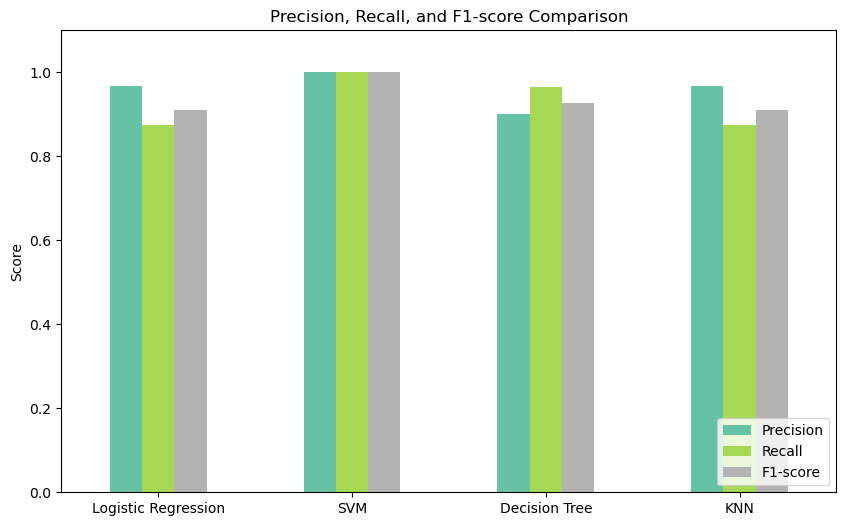

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": logreg_cv,
    "SVM": svm_cv,
    "Decision Tree": tree_cv,
    "KNN": knn_cv
}

# Collect metrics
metrics = {}
for name, model in models.items():
    report = classification_report(Y_test, model.predict(X_test), output_dict=True)
    metrics[name] = {
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1-score": report["macro avg"]["f1-score"]
    }

df_metrics = pd.DataFrame(metrics).T

# Plot grouped bar chart
df_metrics.plot(kind="bar", figsize=(10, 6), colormap="Set2")
plt.title("Precision, Recall, and F1-score Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

#### Comprehensive Classification Metrics Summary Across Models

In [65]:
import pandas as pd
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": logreg_cv,
    "SVM": svm_cv,
    "Decision Tree": tree_cv,
    "KNN": knn_cv
}

# Collect metrics
summary = {}
for name, model in models.items():
    report = classification_report(Y_test, model.predict(X_test), output_dict=True)
    summary[name] = {
        "Accuracy": report["accuracy"],
        "Precision (macro)": report["macro avg"]["precision"],
        "Recall (macro)": report["macro avg"]["recall"],
        "F1-score (macro)": report["macro avg"]["f1-score"]
    }

# Convert to DataFrame
df_summary = pd.DataFrame(summary).T
print(df_summary)

                     Accuracy  Precision (macro)  Recall (macro)  \
Logistic Regression  0.944444           0.966667        0.875000   
SVM                  1.000000           1.000000        1.000000   
Decision Tree        0.944444           0.900000        0.964286   
KNN                  0.944444           0.966667        0.875000   

                     F1-score (macro)  
Logistic Regression          0.911330  
SVM                          1.000000  
Decision Tree                0.925926  
KNN                          0.911330  


#### Random Forest Pipeline with Hyperparameter Tuning and Evaluation

In [66]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_params = {
    'classifier__n_estimators': [50, 100, 200],   # number of trees
    'classifier__criterion': ['gini', 'entropy'], # splitting rule
    'classifier__max_depth': [None, 5, 10, 20],   # tree depth
    'classifier__min_samples_split': [2, 5, 10],  # min samples to split a node
    'classifier__min_samples_leaf': [1, 2, 4],    # min samples per leaf
    'classifier__max_features': ['auto', 'sqrt']  # features considered at each split
}


from sklearn.model_selection import GridSearchCV

rf_cv = GridSearchCV(rf_pipeline, rf_params, cv=5)
rf_cv.fit(X_train, Y_train)

print("Best Parameters:", rf_cv.best_params_)
print("Random Forest Accuracy:", rf_cv.score(X_test, Y_test))

C:\Users\Puneeth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
1080 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1080 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Puneeth\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Puneeth\anaconda3\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Puneeth\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 420, in fit
    self._final

Best Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Random Forest Accuracy: 0.8888888888888888
